# DSS Availability - Monthly Progression

Author: Erick Chauke

Date: May 2026

This notebook turns the monthly availability workbook into one slide-ready chart: each service's monthly availability from April to the latest month, with year-to-date shown alongside. Per-service targets differ and are deliberately left off the chart. It is built section by section, run in VS Code one cell at a time.

## Setup and config

Everything downstream reads from the single config cell below. To point this notebook at a different workbook, change only that cell and run all. The cell after it loads the libraries and resolves the paths.

In [6]:
# CONFIG - the only cell you edit to point at a different dataset
DATA_FILE = "data/availability.xlsx"   # source workbook (gitignored)
YEAR_SHEET = None                       # fiscal-year sheet to chart; None = latest sheet
OUTPUT_DIR = "outputs"                  # where the slide image is saved
Y_AXIS_PAD = 0.5                        # percentage points of headroom around the data range


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_PATH = Path(DATA_FILE)
OUT_PATH = Path(OUTPUT_DIR)
OUT_PATH.mkdir(exist_ok=True)
STEM = DATA_PATH.stem

print("pandas", pd.__version__)
print("data file:", DATA_PATH, "| exists:", DATA_PATH.exists())
print("output dir:", OUT_PATH.resolve())


pandas 2.2.3
data file: data\availability.xlsx | exists: True
output dir: D:\2026\Eskom\DSS availability\availability-visualiser\outputs


## Data ingestion and inspection

The workbook holds one sheet per fiscal year plus a couple of helper sheets. This section discovers the fiscal-year sheets, selects the one to chart (the config value, or the latest year by default), and reads it with no assumed header so we can locate the summary and history blocks ourselves. The raw frame is printed so the real layout is confirmed before any parsing.

In [8]:
import re

xl = pd.ExcelFile(DATA_PATH)

def fiscal_year_start(name):
    m = re.match(r"(\d{4})-\d{4}", name)
    return int(m.group(1)) if m else None

year_sheets = sorted(
    [s for s in xl.sheet_names if fiscal_year_start(s) is not None],
    key=fiscal_year_start,
)
sheet = YEAR_SHEET or year_sheets[-1]

print("all sheets   :", xl.sheet_names)
print("year sheets  :", year_sheets)
print("charting     :", sheet)

raw = pd.read_excel(DATA_PATH, sheet_name=sheet, header=None, na_values=["NULL", "None"])
print("raw shape    :", raw.shape)
print("current month:", raw.iloc[0, 1])
raw


all sheets   : ['2020-2021', '2021-2022', '2022-2023 (2)', '2023-2024', '2024-2025', '2025-2026', '2026-2027', 'Sheet1']
year sheets  : ['2020-2021', '2021-2022', '2022-2023 (2)', '2023-2024', '2024-2025', '2025-2026', '2026-2027']
charting     : 2026-2027
raw shape    : (26, 13)
current month: May


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Month,May,NaN,NaN,NaN,NaN,<--- Change this to get a report for the speci...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Service,Availability,YTD,Target,Comment,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Powi,1,1,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Systemops,0.99998,0.99997,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Themis,1,1,0.9925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,TEMSE HIS,1,0.99999,0.99,NaN,"""http://ncssnagios.eskom.co.za/trends.html""",NaN,NaN,NaN,""" with user/passwod: nagiosadmin""",NaN,NaN
6,NaN,TEMSE NCC,0.99995,0.999955,0.99992,NaN,"""http://systemops.eskom.co.za/temse/downtime/""",NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,TEMSE SCC,0.9993,0.9993,0.9992,NaN,"""SCC availability link on http://encweb1e06"" -...",NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Powi,Powi YTD,Systemops,Systemops YTD,Themis,Themis YTD,TEMSE HIS,HIS YTD,TEMSE NCC,NCC YTD,TEMSE SCC,SCC YTD


## Cleaning and parsing

The history block sits below the summary block in each sheet. We anchor on the April and March month labels to locate it without hard-coding row numbers, pair each service column with the YTD column immediately to its right, and reshape into a tidy long table with one row per service and month. Availability is stored as a fraction in the workbook, so we scale it to a percentage. Numeric coercion is logged. Months with no reading yet (the future months of the current year) are dropped from the monthly series, while the YTD carried in the workbook gives each service its year-to-date figure.

In [9]:
# Locate the history block by anchoring on the April and March month labels
month_labels = raw[0].astype(str).str.strip()
april_idx = month_labels[month_labels == "April"].index[0]
march_idx = month_labels[month_labels == "March"].index[0]
header = raw.iloc[april_idx - 1]

# Pair each service column with the YTD column immediately to its right
service_cols = {}
c = 1
while c < raw.shape[1] and pd.notna(header[c]):
    service_cols[str(header[c]).strip()] = (c, c + 1)
    c += 2

SERVICES = list(service_cols)
print("services:", SERVICES)

# Reshape the month rows into tidy long form, scaling fractions to percentages
hist = raw.iloc[april_idx:march_idx + 1]
months = hist[0].astype(str).str.strip().tolist()

records = []
lost = 0
for svc, (avail_c, ytd_c) in service_cols.items():
    avail = pd.to_numeric(hist[avail_c], errors="coerce")
    ytd = pd.to_numeric(hist[ytd_c], errors="coerce")
    lost += int((avail.isna() & hist[avail_c].notna()).sum())
    lost += int((ytd.isna() & hist[ytd_c].notna()).sum())
    for m, a, y in zip(months, avail, ytd):
        records.append({
            "service": svc,
            "month": m,
            "availability": a * 100 if pd.notna(a) else a,
            "ytd": y * 100 if pd.notna(y) else y,
        })

tidy = pd.DataFrame(records)
tidy["month"] = pd.Categorical(tidy["month"], categories=months, ordered=True)
print("values lost to coercion:", lost)

# Monthly series keeps only months with a real reading; YTD reference is the latest one
monthly = tidy.dropna(subset=["availability"]).copy()
filled_months = monthly["month"].cat.remove_unused_categories().cat.categories.tolist()
latest_month = filled_months[-1]
ytd_now = tidy[tidy["month"] == latest_month].set_index("service")["ytd"]

print("filled months:", filled_months)
print("latest month :", latest_month)
print()
print("current year to date by service:")
print(ytd_now.to_string())
monthly


services: ['Powi', 'Systemops', 'Themis', 'TEMSE HIS', 'TEMSE NCC', 'TEMSE SCC']
values lost to coercion: 0
filled months: ['April', 'May']
latest month : May

current year to date by service:
service
Powi         100.0000
Systemops     99.9970
Themis       100.0000
TEMSE HIS     99.9990
TEMSE NCC     99.9955
TEMSE SCC     99.9300


,service,month,availability,ytd
0,Powi,April,100.000,100.0000
1,Powi,May,100.000,100.0000
12,Systemops,April,99.996,99.9960
13,Systemops,May,99.998,99.9970
24,Themis,April,100.000,100.0000
25,Themis,May,100.000,100.0000
36,TEMSE HIS,April,99.998,99.9980
37,TEMSE HIS,May,100.000,99.9990
48,TEMSE NCC,April,99.996,99.9960
49,TEMSE NCC,May,99.995,99.9955


## Visualisation

One figure, laid out as a compact dashboard with a small panel per service, so it lives on a single slide while still showing each indicator's own month-by-month progression from April to the latest month. Reading one panel at a time, a weak month stands out as a dip rather than being averaged away into the year-to-date figure. The dashed line in each panel is the year to date, the latest month is highlighted with its value, and every panel shares the same zoomed vertical axis so the small real differences between services stay visible and honest, with no panel made to look more dramatic than another. Per-service targets are deliberately left off. The figure is saved to the outputs folder under a name that carries the source file stem, ready to drop onto a single slide.

saved outputs\availability_monthly_availability.png


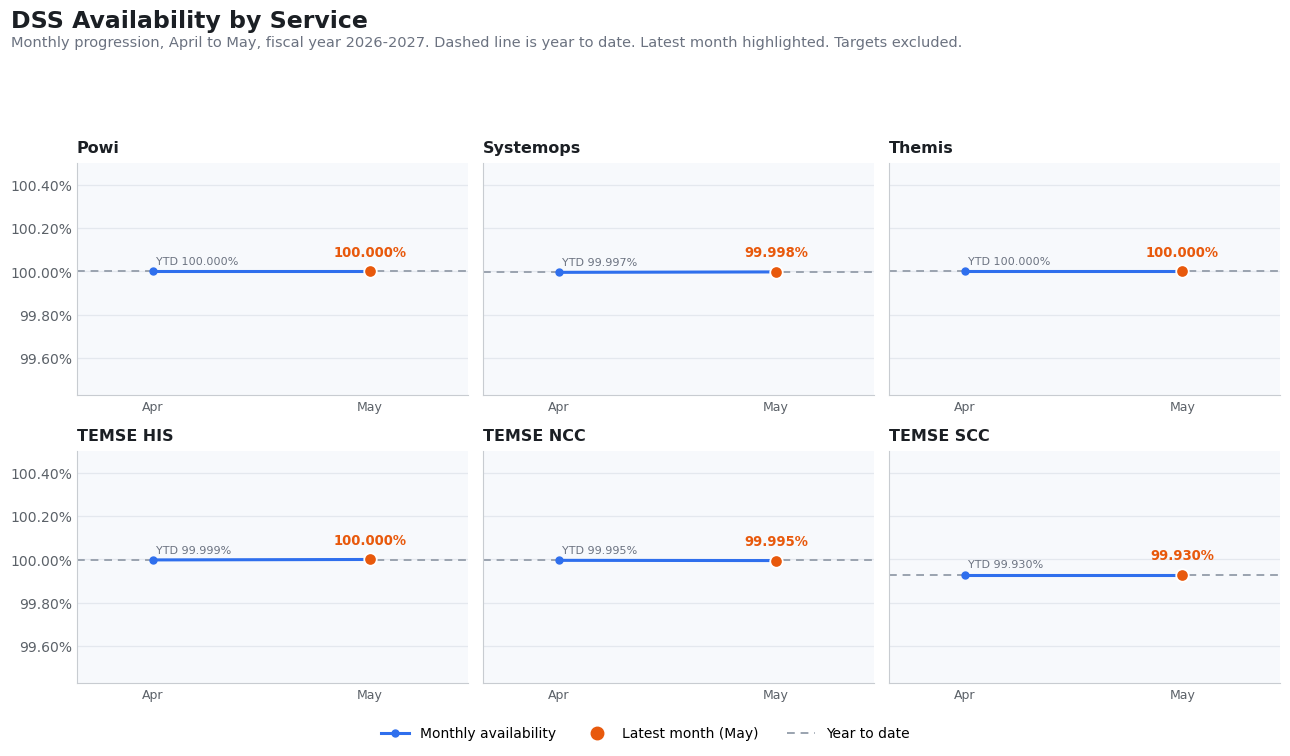

In [10]:
import math

# Cohesive palette for a clean executive dashboard
INK = "#1b1f24"
MUTED = "#6b7280"
LINE = "#2f6fed"      # monthly trend
LATEST = "#e8590c"    # latest month
YTD_C = "#9aa3af"     # year to date
PANEL_BG = "#f7f9fc"

plt.rcParams.update({
    "axes.edgecolor": "#c8ccd1",
    "axes.linewidth": 0.8,
    "xtick.color": "#5b6168",
    "ytick.color": "#5b6168",
})

# Shared, zoomed vertical axis so the tight band of values stays readable
all_vals = pd.concat([monthly["availability"], ytd_now]).dropna()
ymin = all_vals.min() - Y_AXIS_PAD
ymax = min(100 + Y_AXIS_PAD, all_vals.max() + Y_AXIS_PAD)

ncols = 3
nrows = math.ceil(len(SERVICES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 7.4), sharey=True)
fig.patch.set_facecolor("white")
axes = axes.ravel()

x = list(range(len(filled_months)))
xlabels = [str(m)[:3] for m in filled_months]

for ax, svc in zip(axes, SERVICES):
    ax.set_facecolor(PANEL_BG)
    s = monthly[monthly["service"] == svc].sort_values("month")
    yv = s["availability"].tolist()
    yv_ytd = ytd_now[svc]

    # year to date reference line
    ax.axhline(yv_ytd, color=YTD_C, linestyle=(0, (4, 3)), linewidth=1.4, zorder=2)
    ax.annotate(f"YTD {yv_ytd:.3f}%", (0, yv_ytd), textcoords="offset points", xytext=(2, 5),
                ha="left", fontsize=8, color=MUTED)

    # monthly trend, with the latest month picked out
    ax.plot(x, yv, color=LINE, linewidth=2.2, zorder=3)
    ax.plot(x[:-1], yv[:-1], "o", color=LINE, markersize=5, zorder=4)
    ax.plot([x[-1]], [yv[-1]], "o", color=LATEST, markersize=9, zorder=5,
            markeredgecolor="white", markeredgewidth=1.3)
    ax.annotate(f"{yv[-1]:.3f}%", (x[-1], yv[-1]), textcoords="offset points", xytext=(0, 11),
                ha="center", fontsize=9.5, fontweight="bold", color=LATEST)

    ax.set_title(svc, fontsize=11.5, fontweight="bold", color=INK, loc="left", pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_xlim(-0.35, len(filled_months) - 0.55)
    ax.set_ylim(ymin, ymax)
    ax.grid(axis="y", color="#e4e8ee", linewidth=0.9, zorder=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}%"))
    ax.tick_params(length=0)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

for ax in axes[len(SERVICES):]:
    ax.set_visible(False)

fig.suptitle("DSS Availability by Service", x=0.012, y=1.005, ha="left",
             fontsize=17, fontweight="bold", color=INK)
fig.text(0.012, 0.955,
         f"Monthly progression, April to {latest_month}, fiscal year {sheet}. "
         f"Dashed line is year to date. Latest month highlighted. Targets excluded.",
         ha="left", fontsize=10.5, color=MUTED)

handles = [
    plt.Line2D([], [], color=LINE, marker="o", linewidth=2.2, markersize=5,
               label="Monthly availability"),
    plt.Line2D([], [], color=LATEST, marker="o", linestyle="", markersize=9,
               label=f"Latest month ({latest_month})"),
    plt.Line2D([], [], color=YTD_C, linestyle=(0, (4, 3)), linewidth=1.4, label="Year to date"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, 0.0))

fig.tight_layout(rect=[0.0, 0.05, 1, 0.90])

fig_path = OUT_PATH / f"{STEM}_monthly_availability.png"
fig.savefig(fig_path, dpi=170, bbox_inches="tight", facecolor="white")
print("saved", fig_path)
plt.show()


### What the panel view shows

Every service held at or very near full availability through the opening two months of the year. Five of the six sit on the 100 percent line within a few thousandths of a percent, and TEMSE SCC is the single service running lower, steady at 99.930. The reason for giving each service its own panel is not visible yet, and that is the good news: the lines are flat, so neither April nor May hid a weak month behind the year-to-date average. In every panel the dashed year-to-date line sits right under the monthly trend, which confirms the latest month and the running average still agree. The value to the report comes as the year fills out. The moment a service has an off month, that panel's line will drop away from its own year-to-date line and the dip will be impossible to miss, which is exactly the early warning the single snapshot was missing before.

## Alternative view: grouped columns

A second take on the same data for comparison, so the chart style can be chosen on its merits. Services sit along the bottom; within each service a column is drawn for every month from April to the latest, the value is printed on each column because the services run so close together, and the red diamond marks the year to date. It reads cleanly for a few months and gets busier as the year fills out. This figure is saved to the outputs folder under its own name so it does not overwrite the panel view.

saved outputs\availability_monthly_availability_columns.png


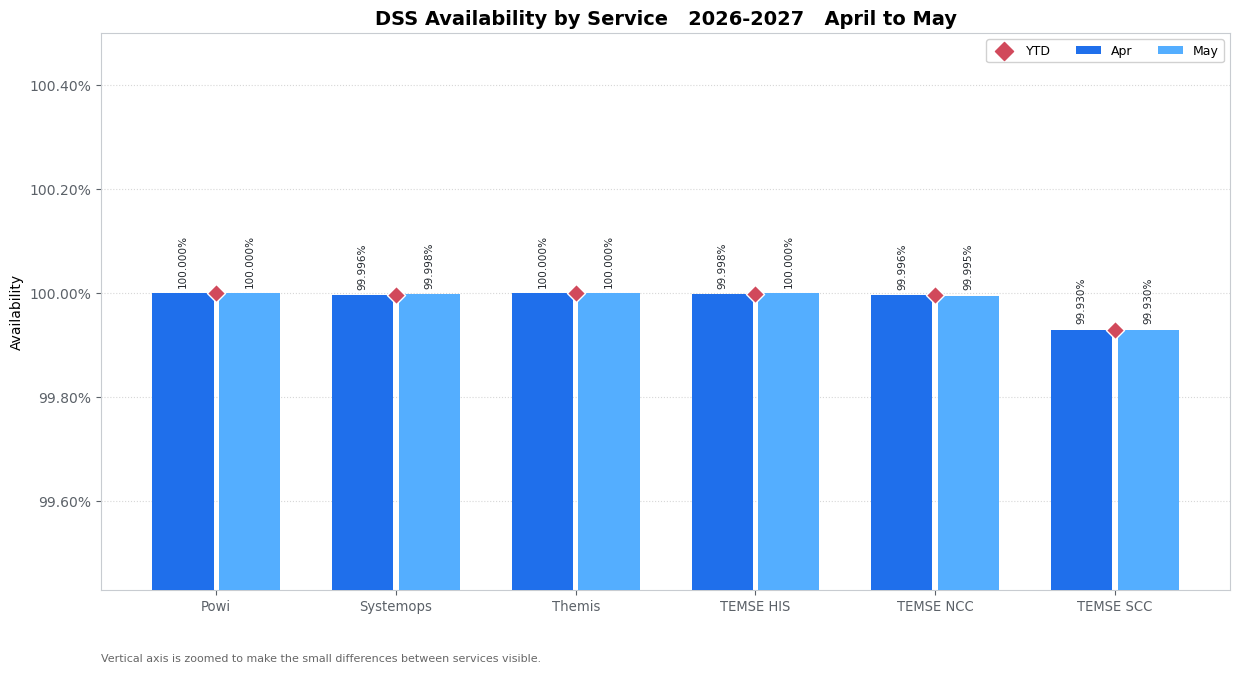

In [11]:
# Months in shades of blue, year to date as a red diamond
COL_MONTH_COLORS = ["#1f6feb", "#54aeff", "#a5d6ff"]
COL_YTD = "#d1495b"

all_vals = pd.concat([monthly["availability"], ytd_now]).dropna()
ymin = all_vals.min() - Y_AXIS_PAD
ymax = min(100 + Y_AXIS_PAD, all_vals.max() + Y_AXIS_PAD)

fig, ax = plt.subplots(figsize=(12.5, 6.8))
fig.patch.set_facecolor("white")
n = len(filled_months)
group_w = 0.74
bar_w = group_w / n
base = list(range(len(SERVICES)))

for j, m in enumerate(filled_months):
    vals = [monthly[(monthly["service"] == s) & (monthly["month"] == m)]["availability"].values[0]
            for s in SERVICES]
    offs = [b - group_w / 2 + bar_w / 2 + j * bar_w for b in base]
    ax.bar(offs, vals, width=bar_w * 0.92, color=COL_MONTH_COLORS[j % len(COL_MONTH_COLORS)],
           label=str(m)[:3], zorder=3)
    for xo, v in zip(offs, vals):
        ax.annotate(f"{v:.3f}%", (xo, v), textcoords="offset points", xytext=(0, 4),
                    ha="center", va="bottom", rotation=90, fontsize=7.5, color="#24292f")

for b, s in zip(base, SERVICES):
    ax.scatter([b], [ytd_now[s]], marker="D", s=85, color=COL_YTD, zorder=4,
               edgecolor="white", linewidth=1)
ax.scatter([], [], marker="D", s=85, color=COL_YTD, label="YTD")

ax.set_xticks(base)
ax.set_xticklabels(SERVICES, fontsize=9.5)
ax.set_ylim(ymin, ymax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}%"))
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.legend(loc="upper right", frameon=True, framealpha=0.9, ncol=n + 1, fontsize=9)
ax.set_title(f"DSS Availability by Service   {sheet}   April to {latest_month}",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Availability")
ax.text(0.0, -0.13, "Vertical axis is zoomed to make the small differences between services visible.",
        transform=ax.transAxes, fontsize=8, color="#666666")
fig.tight_layout()

fig_path_columns = OUT_PATH / f"{STEM}_monthly_availability_columns.png"
fig.savefig(fig_path_columns, dpi=170, bbox_inches="tight", facecolor="white")
print("saved", fig_path_columns)
plt.show()


### What the columns view shows

The same two months read as a straight comparison across services. The bars make it immediate that five services are effectively level at the top while TEMSE SCC sits one visible step below, and the printed values carry the detail the bar heights cannot, since the differences live in the third and fourth decimal. The year-to-date diamond rests on each service's bars, confirming the months and the running average line up. This view answers how the services compare this month at a glance. Its limit is the calendar: late in the year each service will carry up to twelve bars and the comparison will crowd, where the panel view keeps a clean single line per service. Both are saved so the style can be chosen on its merits.

## Summary and observations

This notebook reads the DSS availability workbook, selects the current fiscal year, reshapes the monthly history into a tidy table, and shows each service's monthly availability from April to the latest month with the year to date alongside. Two chart styles are produced from the same data: a panel view with one small trend per service, and a grouped columns view. Both ignore the per-service targets by design and both are sized to sit on a single slide.

Findings for fiscal year 2026-2027, through May:

- All six services are running at or near full availability. Powi and Themis are at 100.000 percent, TEMSE HIS at 100.000 with a year to date of 99.999, Systemops at 99.998, TEMSE NCC at 99.995, and TEMSE SCC at 99.930.
- TEMSE SCC is the one service sitting a clear step below the rest. It is steady rather than declining, but it is the natural candidate to keep an eye on.
- No month so far hides a weak result. For every service the monthly value and the year to date agree, so the opening of the year is clean.

Why the panel view is the recommended default: the request was for monthly progress so that an anomaly in one month is not forgotten. A single year to date number averages a bad month away. The panel view keeps a separate line per service against its own year to date, so the first time any service has an off month the dip will stand out at once. The grouped columns view is kept as an alternative because it compares services well early in the year, with the caveat that it crowds as the months accumulate.

How to reuse this notebook with next month's data: drop the updated workbook into the data folder, point the config cell at it if the name changes, and run all. The latest month, the services present, and the axis range all adapt to the data.

### References

No external references were cited in this notebook. All figures are derived directly from the source workbook in the data folder.